# Analyzing DEX Swaps and NFT Sales Using Python

In this class we will:
- Build mock datasets that mirror real on-chain data (DEX swaps & NFT sales)
- Clean and explore the data with **pandas**
- Visualize trends with **matplotlib** and **seaborn**
- Answer analytical questions like a blockchain data analyst

---
## Prerequisites
```
pip install pandas matplotlib seaborn
```

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
import random
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# Plot style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Setup complete.')

Setup complete.


---
## 2. Mock DEX Swap Data

A DEX (Decentralised Exchange) swap event typically records:

| Field | Description |
|---|---|
| `tx_hash` | Transaction hash |
| `block_number` | Block the tx landed in |
| `timestamp` | Block timestamp |
| `sender` | EOA or contract that initiated the swap |
| `token_in` | Token being sold |
| `token_out` | Token being bought |
| `amount_in` | Raw amount sent in (human-readable here) |
| `amount_out` | Raw amount received |
| `pool` | Liquidity pool address |
| `fee_tier` | Pool fee tier (e.g. 0.05 %, 0.3 %, 1 %) |

In [ ]:
# ── Helper: random hex address ────────────────────────────────────────────────
def rand_addr():
    return '0x' + ''.join(random.choices('0123456789abcdef', k=40))

def rand_tx():
    return '0x' + ''.join(random.choices('0123456789abcdef', k=64))

# ── Tokens on a typical EVM DEX ──────────────────────────────────────────────
TOKENS = ['WETH', 'USDC', 'USDT', 'DAI', 'WBTC', 'ARB', 'OP', 'LINK']

# Rough USD prices for our mock universe
TOKEN_PRICE_USD = {
    'WETH': 3200, 'USDC': 1.0, 'USDT': 1.0, 'DAI': 1.0,
    'WBTC': 62000, 'ARB': 1.2, 'OP': 2.5, 'LINK': 18
}

POOLS = [rand_addr() for _ in range(6)]
FEE_TIERS = [0.0005, 0.003, 0.01]          # 0.05 %, 0.3 %, 1 %

N_SWAPS = 500
BASE_BLOCK = 20_000_000
BASE_TIME  = datetime(2024, 9, 1)

rows = []
for i in range(N_SWAPS):
    token_in, token_out = random.sample(TOKENS, 2)
    price_in  = TOKEN_PRICE_USD[token_in]
    price_out = TOKEN_PRICE_USD[token_out]

    # Trade value between $50 – $50,000
    usd_value  = np.random.lognormal(mean=7, sigma=1.5)
    usd_value  = min(max(usd_value, 50), 50_000)

    amount_in  = round(usd_value / price_in,  6)
    amount_out = round(usd_value / price_out * np.random.uniform(0.995, 1.005), 6)

    block = BASE_BLOCK + i * random.randint(1, 5)
    ts    = BASE_TIME + timedelta(seconds=i * random.randint(12, 60))

    rows.append({
        'tx_hash':      rand_tx(),
        'block_number': block,
        'timestamp':    ts,
        'sender':       rand_addr(),
        'token_in':     token_in,
        'token_out':    token_out,
        'amount_in':    amount_in,
        'amount_out':   amount_out,
        'usd_value':    round(usd_value, 2),
        'pool':         random.choice(POOLS),
        'fee_tier':     random.choice(FEE_TIERS),
    })

swaps = pd.DataFrame(rows)
swaps['timestamp'] = pd.to_datetime(swaps['timestamp'])
print(f'Swap dataset: {swaps.shape[0]} rows x {swaps.shape[1]} cols')
swaps.head()

Swap dataset: 500 rows x 11 cols


,tx_hash,block_number,timestamp,sender,token_in,token_out,amount_in,amount_out,usd_value,pool,fee_tier
0,0x8e3b36a45c17ff134eee52db9fa0d4af211849b3a47e...,20000000,2024-09-01 00:00:00,0x4ecde331ce692edfce0b5ecdc4c1dd3d74c3035d,OP,ARB,924.063228,1929.597914,2310.16,0x849e63f8101ac616f8fd0ba84a167fe482ed4a92,0.003
1,0xf1f2f416b598694b0e8bba51a55db4466426fae94804...,20000005,2024-09-01 00:00:33,0x37d16a3b73a0cc162f803d7caf9fe9b8d8eb743a,OP,ARB,356.492363,743.425151,891.23,0x1a3ed13a32e97cc31667baf165d337643e7d80fd,0.003
2,0xb35e126236570d6cf0e97f46ed8bce7476acbdef8e9a...,20000008,2024-09-01 00:00:32,0x003d9371f7459fbc249e9e6f39d3b4acc908a1a0,DAI,USDT,771.834337,768.423475,771.83,0xc8c8050eed40ef171cc2784d638b34fa78135933,0.003
3,0xe7228a9ec7d953e47c9a57575449e88336837b70463a...,20000009,2024-09-01 00:02:36,0xfd454b2004fac10475f4d1179a2cf138699c6e49,USDC,DAI,771.853345,774.679688,771.85,0xc8c8050eed40ef171cc2784d638b34fa78135933,0.003
4,0x33a22107943bb7aecaae68aed124b941bbf87106541f...,20000004,2024-09-01 00:04:00,0x5b4fd8755f68fa8635cac38e7b1f932881fe71d7,WETH,WBTC,3.661647,0.188082,11717.27,0xfed273606f4c76ff8b24f98b098d2f129a31e399,0.003


---
## 3. Explore the Swap Dataset

In [3]:
swaps.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   tx_hash       500 non-null    str           
 1   block_number  500 non-null    int64         
 2   timestamp     500 non-null    datetime64[us]
 3   sender        500 non-null    str           
 4   token_in      500 non-null    str           
 5   token_out     500 non-null    str           
 6   amount_in     500 non-null    float64       
 7   amount_out    500 non-null    float64       
 8   usd_value     500 non-null    float64       
 9   pool          500 non-null    str           
 10  fee_tier      500 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(5)
memory usage: 43.1 KB


In [23]:
swaps[['usd_value', 'amount_in', 'amount_out']].describe().round(2)

,usd_value,amount_in,amount_out
count,500.00,500.00,500.00
mean,3035.46,1895.41,1590.61
std,5809.17,4734.95,4093.61
min,50.00,0.00,0.00
25%,428.58,18.75,19.83
50%,1122.79,420.97,326.54
75%,2833.39,1493.30,1376.34
max,50000.00,50000.00,49783.54


### 3.1 Which token pairs are most popular?

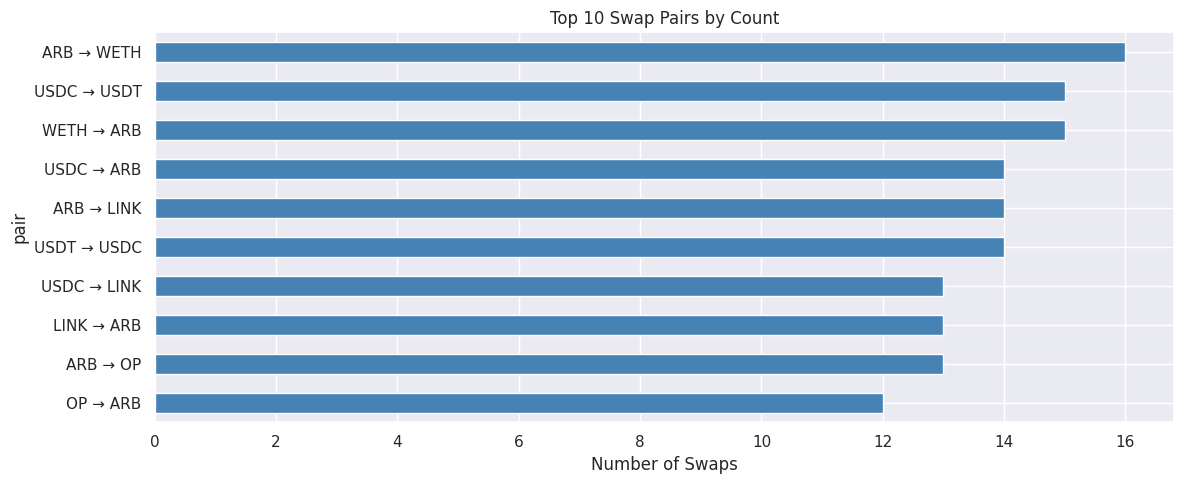

In [25]:
swaps['pair'] = swaps['token_in'] + ' → ' + swaps['token_out']
top_pairs = swaps['pair'].value_counts().head(10)

fig, ax = plt.subplots()
top_pairs.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Swap Pairs by Count')
ax.set_xlabel('Number of Swaps')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 3.2 Daily swap volume (USD)

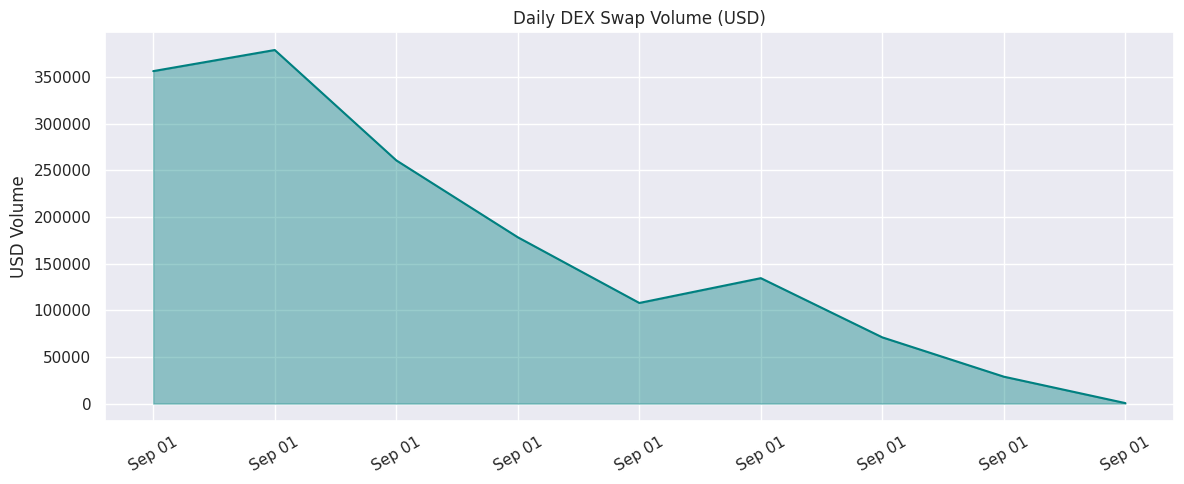

In [27]:
daily_volume = (
    swaps.set_index('timestamp')
         .resample('h')['usd_value']
         .sum()
         .reset_index()
)

fig, ax = plt.subplots()
ax.fill_between(daily_volume['timestamp'], daily_volume['usd_value'], alpha=0.4, color='teal')
ax.plot(daily_volume['timestamp'], daily_volume['usd_value'], color='teal', lw=1.5)
ax.set_title('Daily DEX Swap Volume (USD)')
ax.set_ylabel('USD Volume')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 3.3 Volume by token (sold / bought)

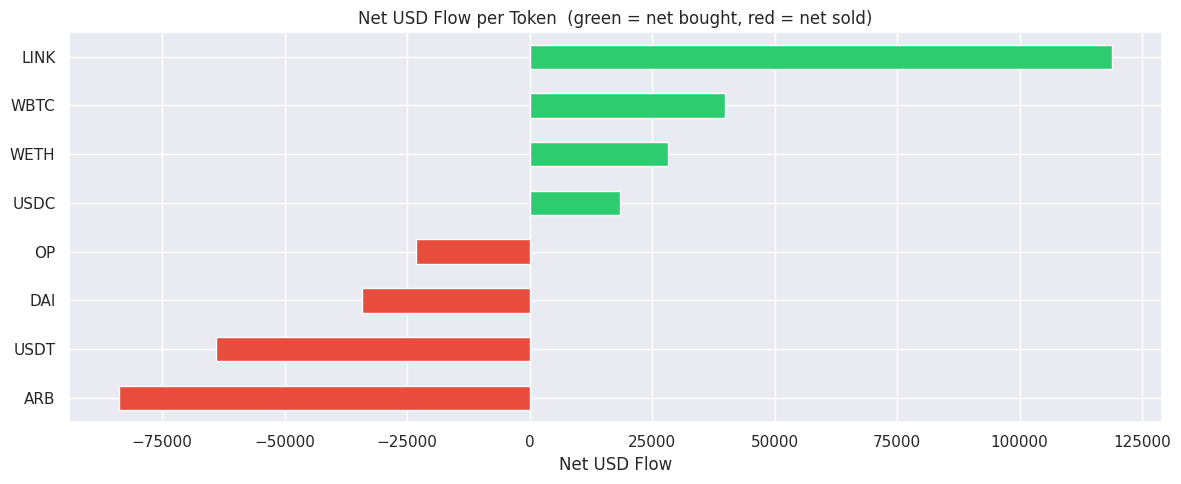

,Sold,Bought,Net Flow
ARB,236144.12,152250.73,-83893.39
USDT,215939.75,151913.30,-64026.45
DAI,212898.68,178652.89,-34245.79
OP,225599.44,202358.03,-23241.41
USDC,225645.90,244107.44,18461.54
WETH,175358.17,203533.20,28175.03
WBTC,115634.75,155529.53,39894.78
LINK,110510.97,229386.66,118875.69


In [7]:
vol_in  = swaps.groupby('token_in')['usd_value'].sum().rename('Sold')
vol_out = swaps.groupby('token_out')['usd_value'].sum().rename('Bought')

token_vol = pd.concat([vol_in, vol_out], axis=1).fillna(0)
token_vol['Net Flow'] = token_vol['Bought'] - token_vol['Sold']
token_vol = token_vol.sort_values('Net Flow')

fig, ax = plt.subplots()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in token_vol['Net Flow']]
token_vol['Net Flow'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='white', lw=0.8)
ax.set_title('Net USD Flow per Token  (green = net bought, red = net sold)')
ax.set_xlabel('Net USD Flow')
plt.tight_layout()
plt.show()

token_vol.round(2)

### 3.4 Distribution of swap sizes

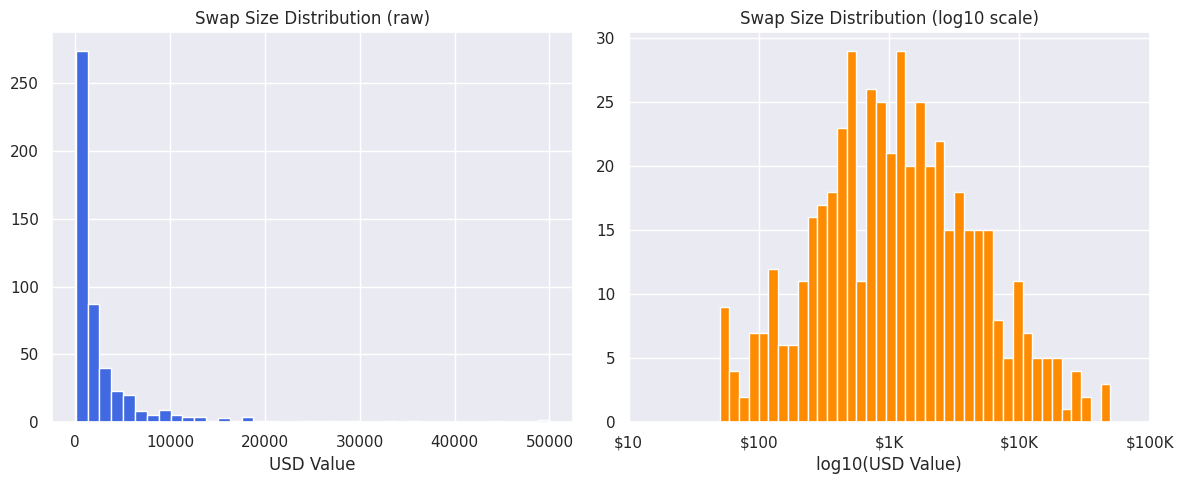

In [8]:
fig, axes = plt.subplots(1, 2)

axes[0].hist(swaps['usd_value'], bins=40, color='royalblue', edgecolor='white')
axes[0].set_title('Swap Size Distribution (raw)')
axes[0].set_xlabel('USD Value')

axes[1].hist(np.log10(swaps['usd_value']), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Swap Size Distribution (log10 scale)')
axes[1].set_xlabel('log10(USD Value)')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].set_xticklabels(['$10', '$100', '$1K', '$10K', '$100K'])

plt.tight_layout()
plt.show()

### 3.5 Fee tier analysis — Which pool tier captures the most volume?

In [9]:
fee_summary = (
    swaps.groupby('fee_tier')
         .agg(swap_count=('tx_hash','count'),
              total_volume=('usd_value','sum'),
              avg_swap_size=('usd_value','mean'))
         .reset_index()
)
fee_summary['fee_tier_pct'] = (fee_summary['fee_tier'] * 100).map(lambda x: f'{x:.2f}%')
fee_summary[['fee_tier_pct','swap_count','total_volume','avg_swap_size']].round(2)

,fee_tier_pct,swap_count,total_volume,avg_swap_size
0,0.05%,160,457849.02,2861.56
1,0.30%,172,501233.29,2914.15
2,1.00%,168,558649.47,3325.29


### 3.6 Identify large (whale) swaps

In [10]:
WHALE_THRESHOLD = swaps['usd_value'].quantile(0.95)
print(f'Whale threshold (95th percentile): ${WHALE_THRESHOLD:,.2f}')

whales = swaps[swaps['usd_value'] >= WHALE_THRESHOLD].copy()
print(f'Whale swaps: {len(whales)} ({len(whales)/len(swaps)*100:.1f}% of all swaps)')
print(f'Whale volume: ${whales["usd_value"].sum():,.2f} '
      f'({whales["usd_value"].sum()/swaps["usd_value"].sum()*100:.1f}% of total volume)')

whales[['timestamp','token_in','token_out','usd_value','pool']].sort_values('usd_value', ascending=False).head(10)

Whale threshold (95th percentile): $11,998.12
Whale swaps: 25 (5.0% of all swaps)
Whale volume: $588,488.38 (38.8% of total volume)


,timestamp,token_in,token_out,usd_value,pool
129,2024-09-01 00:53:45,USDC,LINK,50000.00,0x849e63f8101ac616f8fd0ba84a167fe482ed4a92
382,2024-09-01 05:24:42,OP,USDT,50000.00,0x849e63f8101ac616f8fd0ba84a167fe482ed4a92
69,2024-09-01 00:57:30,USDT,OP,44128.59,0xfed273606f4c76ff8b24f98b098d2f129a31e399
134,2024-09-01 00:53:36,DAI,USDC,35312.34,0xc8c8050eed40ef171cc2784d638b34fa78135933
341,2024-09-01 04:10:04,WETH,WBTC,33058.67,0x849e63f8101ac616f8fd0ba84a167fe482ed4a92
222,2024-09-01 01:32:30,ARB,WETH,29281.30,0xfed273606f4c76ff8b24f98b098d2f129a31e399
220,2024-09-01 02:59:40,OP,USDC,27716.24,0xc8c8050eed40ef171cc2784d638b34fa78135933
152,2024-09-01 01:18:32,USDT,DAI,26455.90,0xfed273606f4c76ff8b24f98b098d2f129a31e399
191,2024-09-01 01:38:41,WETH,LINK,25300.54,0x1a3ed13a32e97cc31667baf165d337643e7d80fd
248,2024-09-01 01:10:16,USDC,ARB,24127.85,0xfed273606f4c76ff8b24f98b098d2f129a31e399


---
## 4. Mock NFT Sales Data

An NFT sale event typically records:

| Field | Description |
|---|---|
| `tx_hash` | Transaction hash |
| `block_number` | Block number |
| `timestamp` | Sale time |
| `collection` | NFT contract address / name |
| `token_id` | ID of the NFT sold |
| `seller` | Previous owner |
| `buyer` | New owner |
| `price_eth` | Sale price in ETH |
| `price_usd` | Sale price in USD |
| `marketplace` | Where the sale happened |

In [11]:
COLLECTIONS = {
    'BoredApeYC':        {'floor_eth': 12.0,  'supply': 10_000},
    'CryptoPunks':       {'floor_eth': 38.0,  'supply': 10_000},
    'Azuki':             {'floor_eth': 4.5,   'supply': 10_000},
    'Pudgy Penguins':    {'floor_eth': 7.0,   'supply': 8_888},
    'Doodles':           {'floor_eth': 1.8,   'supply': 10_000},
    'Art Blocks Curated':{'floor_eth': 0.6,   'supply': 5_000},
}

MARKETPLACES = ['OpenSea', 'Blur', 'LooksRare', 'X2Y2']
MARKETPLACE_WEIGHTS = [0.35, 0.40, 0.15, 0.10]   # Blur dominates by volume

ETH_PRICE_USD = 3200

N_SALES = 300
BASE_NFT_TIME = datetime(2024, 9, 1)

nft_rows = []
for i in range(N_SALES):
    col_name  = random.choice(list(COLLECTIONS.keys()))
    col_data  = COLLECTIONS[col_name]
    floor     = col_data['floor_eth']

    # Price varies ±60 % around floor with occasional 10x spike
    multiplier = np.random.lognormal(mean=0, sigma=0.4)
    price_eth  = round(floor * multiplier, 4)

    price_usd  = round(price_eth * ETH_PRICE_USD, 2)
    ts         = BASE_NFT_TIME + timedelta(seconds=i * random.randint(30, 600))

    nft_rows.append({
        'tx_hash':      rand_tx(),
        'block_number': BASE_BLOCK + i * random.randint(1, 10),
        'timestamp':    ts,
        'collection':   col_name,
        'token_id':     random.randint(1, col_data['supply']),
        'seller':       rand_addr(),
        'buyer':        rand_addr(),
        'price_eth':    price_eth,
        'price_usd':    price_usd,
        'marketplace':  random.choices(MARKETPLACES, weights=MARKETPLACE_WEIGHTS)[0],
    })

nfts = pd.DataFrame(nft_rows)
nfts['timestamp'] = pd.to_datetime(nfts['timestamp'])
print(f'NFT dataset: {nfts.shape[0]} rows x {nfts.shape[1]} cols')
nfts.head()

NFT dataset: 300 rows x 10 cols


,tx_hash,block_number,timestamp,collection,token_id,seller,buyer,price_eth,price_usd,marketplace
0,0xa21cf8cbe73b2ede7f7309c40f3c42344c1754b032a3...,20000000,2024-09-01 00:00:00,Doodles,9944,0xa3062d4ef7ccde91768b96b0295ba01f400b2ea3,0x6178d51eed8f4efd49504aba1b04cc7ded8d5232,1.4087,4507.84,Blur
1,0x133802e07703383cd67abd5eefd82fd46454c4eba824...,20000006,2024-09-01 00:05:32,Azuki,53,0xd695dab999facc7332f938bd5c5ade085847dae2,0x91dfb6135f16a0b07ee40dccaa10bbcd73db6253,3.8536,12331.52,LooksRare
2,0xd51f2fd6ce2fea0297bd130027b0a95af842318ab262...,20000006,2024-09-01 00:16:50,Doodles,94,0x5ddcb7cdd3b039859edb843ae3fa09308cc31147,0x59861638bf303eea755c232a8e1fa958d03d2743,2.0181,6457.92,OpenSea
3,0x4dd3ebc823d3322093e7b065525e2b30154805a138b7...,20000021,2024-09-01 00:28:48,CryptoPunks,1556,0x357c30d55db3a14da7718be92aee965851498d2f,0x4a46d9c257df7b34c5f72437a0f8c4cee621255f,43.4395,139006.40,OpenSea
4,0x967526842d9cc9ca3e9e67ce59c56cb4b6d7189a2671...,20000032,2024-09-01 00:21:52,Azuki,6346,0x9f9b26c49a060f9f2bad8e773ad321f8cb2ad875,0xae5ac934e8c097a7ad23acea662bff89e98e3c6b,5.8562,18739.84,Blur


---
## 5. Explore the NFT Dataset

### 5.1 Sales count and total volume per collection

In [12]:
col_summary = (
    nfts.groupby('collection')
        .agg(sales=('tx_hash','count'),
             total_eth=('price_eth','sum'),
             total_usd=('price_usd','sum'),
             avg_price_eth=('price_eth','mean'),
             max_price_eth=('price_eth','max'))
        .sort_values('total_eth', ascending=False)
        .round(3)
)
col_summary

,sales,total_eth,total_usd,avg_price_eth,max_price_eth
collection,,,,,
CryptoPunks,50,2055.653,6578089.92,41.113,69.335
BoredApeYC,50,693.374,2218795.84,13.867,29.544
Azuki,55,299.940,959807.36,5.453,11.769
Pudgy Penguins,30,254.190,813408.96,8.473,16.491
Doodles,70,144.005,460815.68,2.057,4.131
Art Blocks Curated,45,29.202,93447.04,0.649,1.649


### 5.2 Volume breakdown by collection (pie chart)

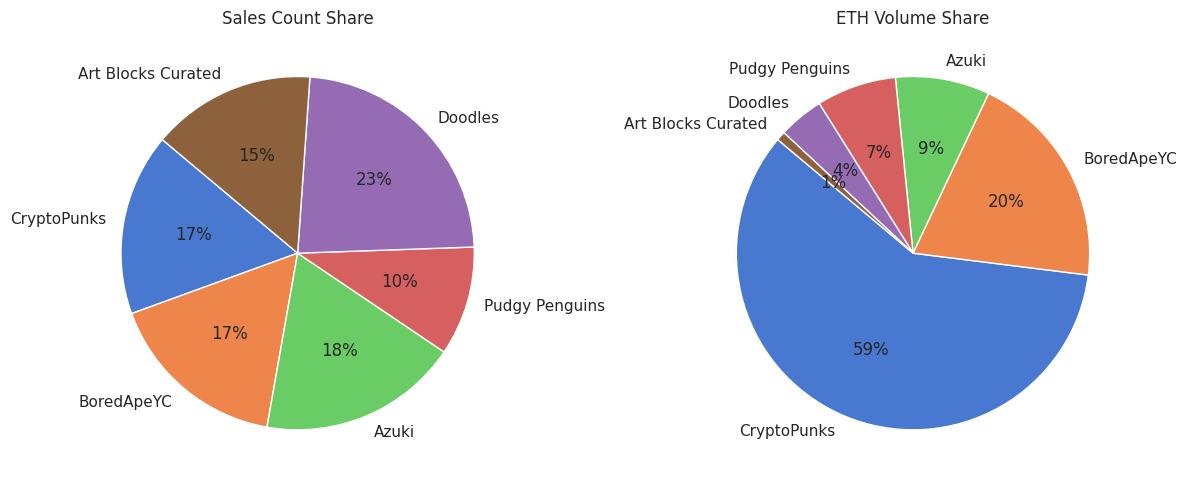

In [13]:
fig, axes = plt.subplots(1, 2)

col_summary['sales'].plot(kind='pie', ax=axes[0], autopct='%1.0f%%',
                          startangle=140, ylabel='')
axes[0].set_title('Sales Count Share')

col_summary['total_eth'].plot(kind='pie', ax=axes[1], autopct='%1.0f%%',
                              startangle=140, ylabel='')
axes[1].set_title('ETH Volume Share')

plt.tight_layout()
plt.show()

### 5.3 Price distribution per collection (box plot)

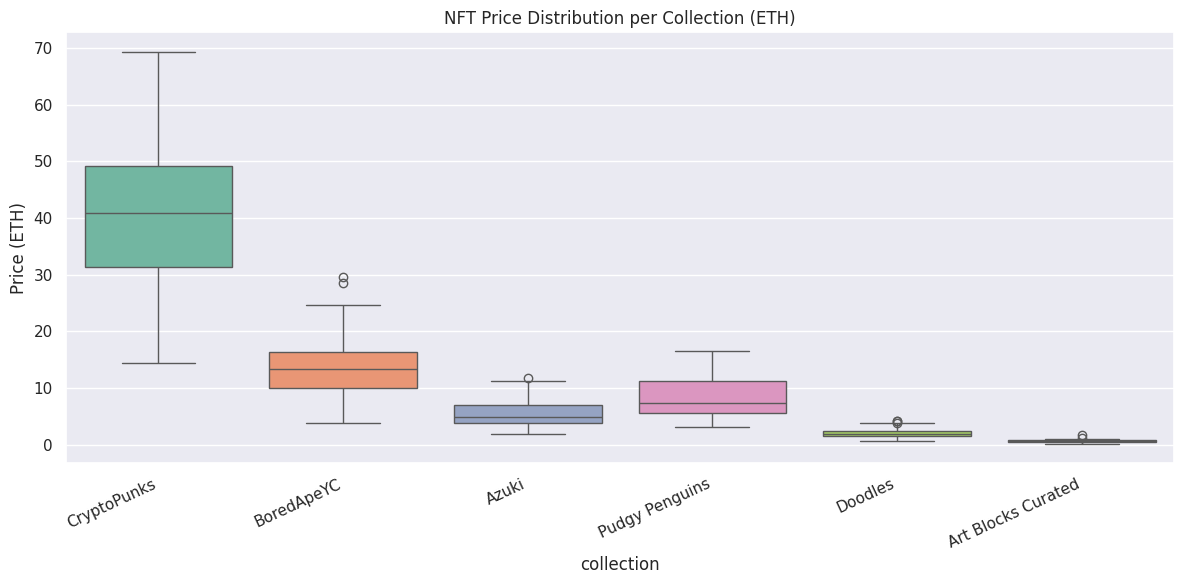

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
order = col_summary.index.tolist()
sns.boxplot(data=nfts, x='collection', y='price_eth',
            order=order, palette='Set2', ax=ax)
ax.set_title('NFT Price Distribution per Collection (ETH)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_ylabel('Price (ETH)')
plt.tight_layout()
plt.show()

### 5.4 Marketplace market share

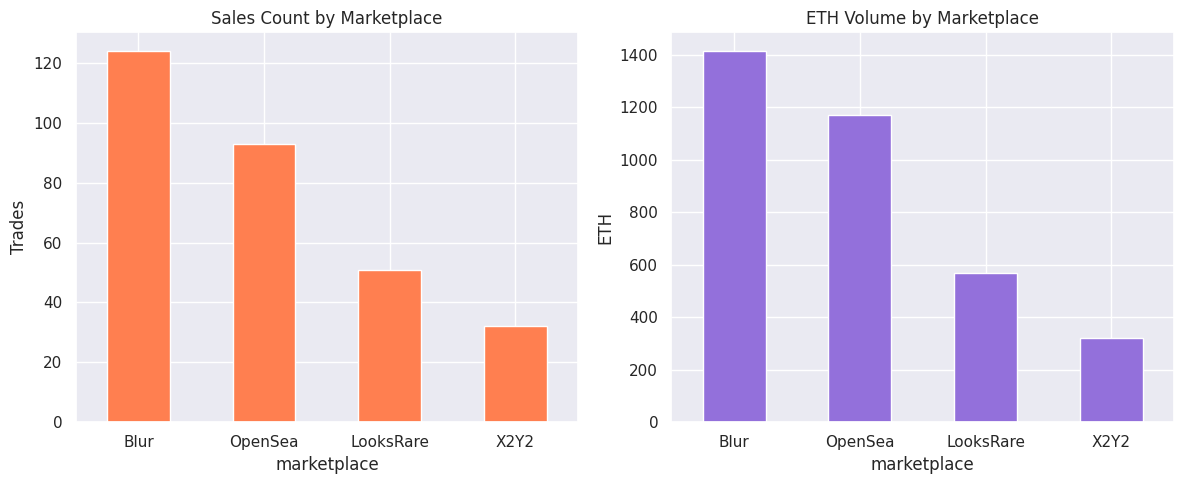

,sales,volume_eth
marketplace,,
Blur,124,1415.615
OpenSea,93,1170.844
LooksRare,51,568.003
X2Y2,32,321.902


In [15]:
mp = nfts.groupby('marketplace').agg(
    sales=('tx_hash','count'),
    volume_eth=('price_eth','sum')
).sort_values('volume_eth', ascending=False)

fig, axes = plt.subplots(1, 2)
mp['sales'].plot(kind='bar', ax=axes[0], color='coral', rot=0)
axes[0].set_title('Sales Count by Marketplace')
axes[0].set_ylabel('Trades')

mp['volume_eth'].plot(kind='bar', ax=axes[1], color='mediumpurple', rot=0)
axes[1].set_title('ETH Volume by Marketplace')
axes[1].set_ylabel('ETH')

plt.tight_layout()
plt.show()
mp.round(3)

### 5.5 Daily NFT sales volume over time

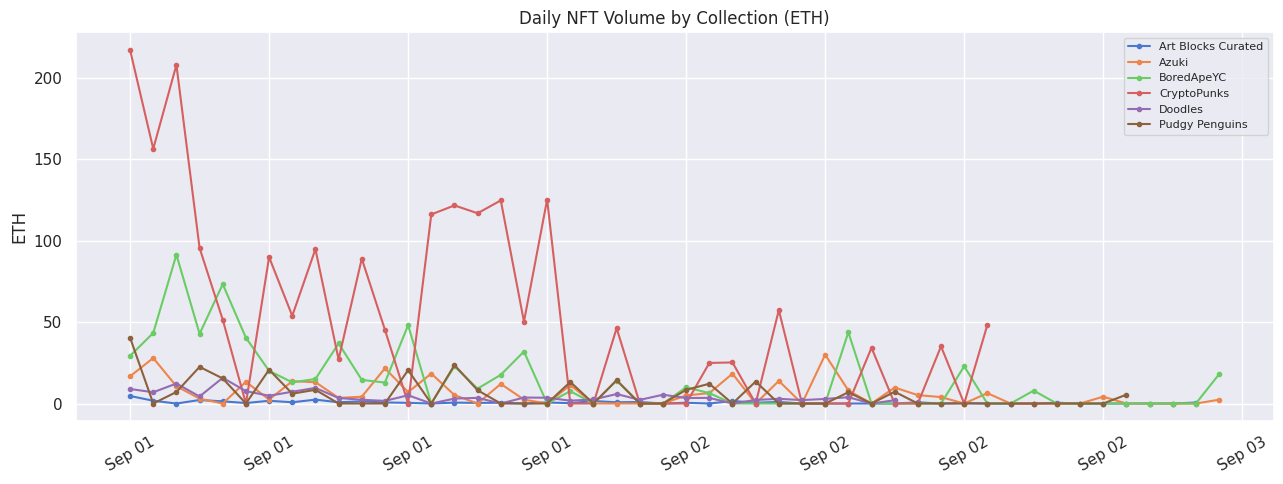

In [28]:
daily_nft = (
    nfts.set_index('timestamp')
        .groupby('collection')
        .resample('h')['price_eth']
        .sum()
        .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 5))
for col, grp in daily_nft.groupby('collection'):
    ax.plot(grp['timestamp'], grp['price_eth'], marker='o', ms=3, label=col)

ax.set_title('Daily NFT Volume by Collection (ETH)')
ax.set_ylabel('ETH')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

---
## 6. Cross-Dataset Analysis: DEX Volume vs. NFT Volume

On active days NFT traders often sell tokens to fund purchases. Let's check if DEX swap volume and NFT sales volume are correlated.

Pearson correlation (DEX vs NFT daily volume): 0.7546


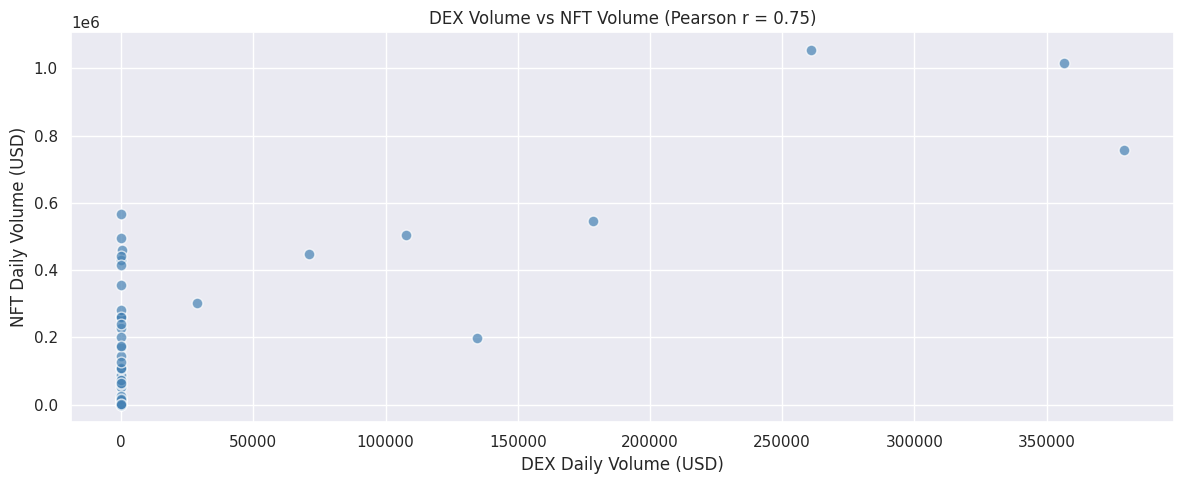

In [29]:
dex_daily = (
    swaps.set_index('timestamp')
         .resample('h')['usd_value']
         .sum()
         .rename('dex_volume_usd')
)

nft_daily = (
    nfts.set_index('timestamp')
        .resample('h')['price_usd']
        .sum()
        .rename('nft_volume_usd')
)

combined = pd.concat([dex_daily, nft_daily], axis=1).fillna(0).reset_index()

corr = combined['dex_volume_usd'].corr(combined['nft_volume_usd'])
print(f'Pearson correlation (DEX vs NFT daily volume): {corr:.4f}')

fig, ax = plt.subplots()
ax.scatter(combined['dex_volume_usd'], combined['nft_volume_usd'],
           alpha=0.7, color='steelblue', edgecolor='white', s=60)
ax.set_title(f'DEX Volume vs NFT Volume (Pearson r = {corr:.2f})')
ax.set_xlabel('DEX Daily Volume (USD)')
ax.set_ylabel('NFT Daily Volume (USD)')
plt.tight_layout()
plt.show()

---
## 7. Exercises

Try these on your own using the datasets above:

1. **Swap heatmap** — Create a pivot table of `token_in` × `token_out` showing total USD volume. Visualise it as a heatmap.

2. **Top traders** — Find the top 10 wallet addresses by total USD swap volume. Are any addresses appearing on both the buy and sell side heavily?

3. **NFT flip detector** — Identify token IDs within the same collection that appear more than once in `nfts`. Calculate the profit/loss in ETH for each flip.

4. **Rolling average** — Plot a 7-day rolling average on top of the daily DEX volume chart.

5. **Anomaly detection** — Flag swaps whose `usd_value` is more than 3 standard deviations above the mean. Print their details.

In [18]:
# Exercise 1 — Swap heatmap
# Your code here


In [19]:
# Exercise 2 — Top traders
# Your code here


In [20]:
# Exercise 3 — NFT flip detector
# Your code here


In [21]:
# Exercise 4 — Rolling average
# Your code here


In [22]:
# Exercise 5 — Anomaly detection
# Your code here
